# Subject hold-out PhysioNetMI — Left vs Right

Pipeline de taller con evaluación hold-out por sujetos:

```text
filtros -> EA -> FBCSP -> selección supervisada -> StandardScaler -> LDA shrinkage -> TEST hold-out
```

Características de esta versión:
- Usa todos los canales EEG disponibles.
- No usa ROI.
- No usa CSD/Laplacian.
- No usa PCA.
- Deja únicamente LDA shrinkage como modelo final.
- Mantiene una celda opcional para cargar features guardadas.


In [ ]:
# En Google Colab, descomenta si necesitas instalar dependencias:
!pip -q install moabb mne scikit-learn

In [1]:
import os
import warnings
import gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
from scipy.linalg import fractional_matrix_power

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)

import mne
from mne.decoding import CSP

from moabb.datasets import PhysionetMI
from moabb.paradigms import MotorImagery

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")


## 1. Configuración general

In [2]:
# =========================================================
# CONFIGURACIÓN GENERAL DEL TALLER
# =========================================================
# Pipeline único:
#     filtros -> EA -> FBCSP -> selección supervisada -> StandardScaler -> LDA shrinkage
# No hay ROI, CSD/Laplacian ni PCA.

sfreq = 160
random_state = 42

# Split experimental
test_size = 0.20              # cambia 0.10, 0.20 o 0.30 para variar el tamaño del TEST hold-out

# Clasificación binaria
BINARY_EVENTS = ["left_hand", "right_hand"]
LABEL_NAME_TO_ID = {"left_hand": 1, "right_hand": 2}
LABEL_ORDER = [1, 2]
LABEL_NAMES = ["left_hand", "right_hand"]
LABEL_ID_TO_NAME = dict(zip(LABEL_ORDER, LABEL_NAMES))

# Outliers
outlier_uv = 800.0            # prueba 500, 800 o 1000 µV y revisa cuántos trials elimina
AUTO_DETECT_OUTLIER_UNITS = True

# Filtros base antes de EA
highpass_hz = 4.0             # prueba 1.0, 2.0 o 4.0 Hz
highpass_order = 4            # orden del high-pass

# Variante única del pipeline
ACTIVE_VARIANT = "ea_fbcsp_all_channels_lda_shrinkage"
USE_EA = True                 # EA: cambia a False para comparar sin alineación euclidiana

# =============================
# Variables modificables de EA
# =============================
EA_REG = 1e-10                # regularización para R^{-1/2}; si hay inestabilidad prueba 1e-8 o 1e-6
EA_VERIFY_ENABLED = True      # verifica que la covarianza media tras EA sea cercana a identidad

# =============================
# Variables modificables de FBCSP
# =============================
freq_bands = [                # banco de filtros; prueba bandas solapadas o solo mu/beta
    (4, 8),
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 28),
    (28, 32),
    (32, 36),
]
bandpass_order = 5            # orden del filtro por banda
n_csp_components = 4          # componentes CSP por banda; prueba 2, 4, 6 u 8
fbcsp_reg = "ledoit_wolf"     # regularización CSP; prueba None, 0.1 o "ledoit_wolf"
fbcsp_norm_trace = True       # True aproxima log-varianza normalizada clásica

# Selección supervisada de características FBCSP
USE_FBCSP_FEATURE_SELECTION = True
FBCSP_FEATURE_SELECTION_K = 16 # prueba None, 8, 16, 24, 32

# Guardado/carga opcional de features
FEATURES_DIR_NAME = "features_binary_left_right_ea_fbcsp_workshop_lda_only"
LOAD_FEATURES_IF_AVAILABLE = False
SAVE_FEATURES_AFTER_EXTRACTION = True


## 2. Google Drive, dataset y paradigma binario

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    drive_mne_path = "/content/drive/MyDrive/mne_data"
except Exception:
    drive_mne_path = os.path.expanduser("~/mne_data")

os.makedirs(drive_mne_path, exist_ok=True)
mne.set_config("MNE_DATA", drive_mne_path, set_env=True)
mne.set_config("MOABB_DATA", drive_mne_path, set_env=True)

dataset = PhysionetMI()
#dataset.download(path=drive_mne_path)

# Solo left/right; se elimina rest desde la fuente del paradigma
paradigm = MotorImagery(
    events=BINARY_EVENTS,
    n_classes=2
)

### 2.1 Datos locales

In [3]:
import mne

# Ver qué tiene guardado actualmente
print("MNE_DATA:", mne.get_config("MNE_DATA"))
print("MOABB_DATA:", mne.get_config("MOABB_DATA"))

# Sobrescribir con la ruta correcta
mne.set_config("MNE_DATA", r"E:\mne_data", set_env=True)
mne.set_config("MOABB_DATA", r"E:\mne_data", set_env=True)

# Verificar
print("MNE_DATA nuevo:", mne.get_config("MNE_DATA"))

MNE_DATA: E:\mne_data
MOABB_DATA: E:\mne_data
MNE_DATA nuevo: E:\mne_data


In [6]:
print(mne.get_config_path())

C:\Users\eduar\.mne\mne-python.json


In [3]:
# Ruta local donde ya están los datos descargados
local_data_path = r"E:\mne_data"

mne.set_config("MNE_DATA", local_data_path, set_env=True)
mne.set_config("MOABB_DATA", local_data_path, set_env=True)

dataset = PhysionetMI()
#dataset.download(path=local_data_path)

# Solo left/right; se elimina rest desde la fuente del paradigma
paradigm = MotorImagery(
    events=BINARY_EVENTS,
    n_classes=2
)

## 3. Canales reales y normalización de nombres

In [21]:
def normalize_physionet_ch_name(ch):
    """Normaliza nombres de canales para diagnóstico de consistencia."""
    ch = str(ch).strip()
    ch = ch.replace(".", "")
    return ch.upper()


def get_real_eeg_ch_names(dataset, subject):
    data = dataset.get_data(subjects=[subject])
    subject_key = next(iter(data.keys()))
    session_key = next(iter(data[subject_key].keys()))
    run_key = next(iter(data[subject_key][session_key].keys()))
    raw = data[subject_key][session_key][run_key]
    return [ch for ch in raw.info["ch_names"] if ch.upper() != "STIM"]

REAL_EEG_CH_NAMES = get_real_eeg_ch_names(dataset, subject = 1)
NORMALIZED_EEG_CH_NAMES = [normalize_physionet_ch_name(ch) for ch in REAL_EEG_CH_NAMES]

print("N canales:", len(REAL_EEG_CH_NAMES))
print("Primeros canales reales:", REAL_EEG_CH_NAMES[:10])
print("Primeros canales normalizados:", NORMALIZED_EEG_CH_NAMES[:10])


N canales: 64
Primeros canales reales: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']
Primeros canales normalizados: ['FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']


## 4. Carga/cache de datos por sujeto — solo left/right

In [25]:
def labels_to_binary_int(labels_arr):
    labels_arr = np.asarray(labels_arr).astype(str)
    labels_int = np.array([LABEL_NAME_TO_ID[str(lbl)] for lbl in labels_arr], dtype=int)
    return labels_int


def build_subject_data(dataset, paradigm, subject_ids):
    subj_data = {}

    for sid in subject_ids:
        print(f"Procesando sujeto {sid}...")
        try:
            X_s, y_s, metadata_s = paradigm.get_data(dataset=dataset, subjects=[sid])
        except Exception as e:
            print(f"  Saltando sujeto {sid}: {e}")
            continue

        if X_s.ndim != 3 or X_s.shape[0] == 0:
            print(f"  Sujeto {sid} sin epochs válidas.")
            continue

        y_s = np.asarray(y_s).astype(str)
        valid_mask = np.isin(y_s, BINARY_EVENTS)
        X_s = X_s[valid_mask]
        y_s = y_s[valid_mask]
        metadata_s = metadata_s.iloc[np.where(valid_mask)[0]].reset_index(drop=True)

        if X_s.shape[0] == 0:
            print(f"  Sujeto {sid} sin epochs left/right.")
            continue

        n_epochs, n_ch, n_times = X_s.shape
        if n_ch != len(REAL_EEG_CH_NAMES):
            raise ValueError(f"Sujeto {sid}: X tiene {n_ch} canales; se esperaban {len(REAL_EEG_CH_NAMES)}.")

        # MOABB entrega X como (n_epochs, n_channels, n_times).
        # Guardamos cada trial como (n_times, n_channels) para mantener el flujo anterior.
        trials_s = [X_s[i].T.astype(np.float32) for i in range(n_epochs)]
        labels_s = labels_to_binary_int(y_s)

        run_col_s = metadata_s["run"].values if "run" in metadata_s.columns else np.zeros(n_epochs, dtype=int)
        session_col_s = (
            np.asarray(metadata_s["session"].values, dtype=object)
            if "session" in metadata_s.columns
            else np.array(["session_0"] * n_epochs, dtype=object)
        )

        run_ids_s = np.zeros(n_epochs, dtype=np.int64)
        seen_s = {}
        current_run_id = 0
        for i, k in enumerate(zip(session_col_s, run_col_s)):
            if k not in seen_s:
                seen_s[k] = current_run_id
                current_run_id += 1
            run_ids_s[i] = seen_s[k]

        subj_data[sid] = {
            "trials": trials_s,
            "labels": labels_s,
            "run_ids": run_ids_s,
            "label_map": LABEL_NAME_TO_ID.copy(),
            "label_names": BINARY_EVENTS.copy(),
            "original_labels_seq": y_s,
            "ch_names": REAL_EEG_CH_NAMES.copy(),
            "n_epochs": n_epochs,
            "n_channels": n_ch,
            "n_times": n_times,
        }

    return subj_data

subj_data = build_subject_data(dataset, paradigm, dataset.subject_list[:2])

print("Sujetos cargados:", len(subj_data))

Procesando sujeto 1...
Procesando sujeto 2...
Sujetos cargados: 2


## 5. Utilidades de estructura, split por sujeto y diagnóstico de outliers

In [26]:
def validate_subject_dict(data_dict, expected_n_channels=None):
    for sid, sdata in data_dict.items():
        trials = sdata["trials"]
        labels = sdata["labels"]
        run_ids = sdata["run_ids"]
        if not (len(trials) == len(labels) == len(run_ids)):
            raise ValueError(f"Sujeto {sid}: inconsistencia trials/labels/run_ids.")
        for i, trial in enumerate(trials):
            if trial.ndim != 2:
                raise ValueError(f"Sujeto {sid}, trial {i}: shape inválido {trial.shape}")
            if expected_n_channels is not None and trial.shape[1] != expected_n_channels:
                raise ValueError(f"Sujeto {sid}, trial {i}: {trial.shape[1]} canales; esperados {expected_n_channels}")


def summarize_subject_dict(name, data_dict):
    all_labels = []
    shapes = []
    for v in data_dict.values():
        all_labels.extend(v["labels"])
        shapes.extend([tuple(t.shape) for t in v["trials"]])
    all_labels = np.asarray(all_labels)
    unique, counts = np.unique(all_labels, return_counts=True) if len(all_labels) else ([], [])
    print(f"\n--- {name} ---")
    print("Sujetos:", len(data_dict))
    print("Trials:", sum(len(v["trials"]) for v in data_dict.values()))
    print("Distribución labels:", {LABEL_ID_TO_NAME.get(int(k), str(k)): int(v) for k, v in zip(unique, counts)})
    print("Shapes de trials más comunes:", Counter(shapes).most_common(5))


def flatten_subject_dict(data_dict):
    X_list, y_list, groups, run_ids = [], [], [], []
    for sid, sdata in data_dict.items():
        for i, trial in enumerate(sdata["trials"]):
            X_list.append(trial)
            y_list.append(sdata["labels"][i])
            groups.append(sid)
            run_ids.append(sdata["run_ids"][i])
    return X_list, np.asarray(y_list, dtype=int), np.asarray(groups), np.asarray(run_ids, dtype=int)


def report_trial_shapes(X_list, title="trial shapes", max_rows=10):
    """Diagnóstico rápido para detectar trials con diferente n_times/n_channels."""
    shapes = [tuple(x.shape) for x in X_list]
    counts = Counter(shapes)
    print(f"\n[{title}] total trials={len(X_list)} | unique shapes={len(counts)}")
    for shape, n in counts.most_common(max_rows):
        print(f"  shape={shape}: {n} trials")
    return counts


def crop_or_pad_trial_time(trial, target_n_times, mode="crop"):
    """Asegura shape temporal común manteniendo canales.

    trial: (n_times, n_channels)
    mode='crop': recorta al mínimo común. Recomendado para Physionet cuando hay 480/481 muestras.
    mode='pad': rellena al final con ceros si falta tiempo.
    """
    n_times, n_channels = trial.shape
    if n_times == target_n_times:
        return trial.astype(np.float32, copy=False)

    if n_times > target_n_times:
        # Recorte centrado para no sesgar siempre el inicio o el final.
        start = (n_times - target_n_times) // 2
        return trial[start:start + target_n_times, :].astype(np.float32, copy=False)

    if mode == "pad":
        out = np.zeros((target_n_times, n_channels), dtype=np.float32)
        out[:n_times, :] = trial.astype(np.float32, copy=False)
        return out

    raise ValueError(
        f"Trial con n_times={n_times} menor que target_n_times={target_n_times}. "
        "Usa mode='pad' o revisa la extracción de epochs."
    )


def trials_list_to_3d(X_list, target_n_times=None, target_n_channels=None, crop_mode="crop", verbose=True):
    """Lista (n_times, n_channels) -> array (n_trials, n_channels, n_times).

    Esta versión evita el error:
        ValueError: all input arrays must have the same shape

    Causa típica: algunos epochs quedan con 480 y otros con 481 muestras.
    """
    if len(X_list) == 0:
        raise ValueError("X_list está vacío; no hay trials para convertir.")

    if verbose:
        report_trial_shapes(X_list, title="trials_list_to_3d input")

    n_times_all = [trial.shape[0] for trial in X_list]
    n_channels_all = [trial.shape[1] for trial in X_list]

    if target_n_channels is None:
        channel_counts = Counter(n_channels_all)
        target_n_channels = channel_counts.most_common(1)[0][0]

    bad_ch = [i for i, trial in enumerate(X_list) if trial.shape[1] != target_n_channels]
    if bad_ch:
        examples = [(i, X_list[i].shape) for i in bad_ch[:10]]
        raise ValueError(
            f"Hay trials con número de canales diferente a {target_n_channels}. "
            f"Ejemplos: {examples}"
        )

    if target_n_times is None:
        # Usar el mínimo evita interpolar o inventar datos. En PhysioNet suele ser 480/481.
        target_n_times = int(np.min(n_times_all))

    X_fixed = [crop_or_pad_trial_time(trial, target_n_times, mode=crop_mode).T for trial in X_list]
    X = np.stack(X_fixed, axis=0).astype(np.float32)

    if verbose:
        print(f"Salida 3D: {X.shape} = (trials, channels, times) | target_n_times={target_n_times}")

    return X


def harmonize_subject_dict_time(data_dict, target_n_times=None, crop_mode="crop", verbose=False, name="data"):
    """Recorta todos los trials de un subject_dict a un mismo n_times."""
    all_trials = [trial for sdata in data_dict.values() for trial in sdata["trials"]]
    if len(all_trials) == 0:
        raise ValueError(f"{name}: no hay trials.")

    n_times_all = [trial.shape[0] for trial in all_trials]
    if target_n_times is None:
        target_n_times = int(np.min(n_times_all))

    if verbose:
        print(f"[{name}] armonizando longitud temporal a {target_n_times} muestras")
        report_trial_shapes(all_trials, title=f"{name} before harmonization")

    out = {}
    for sid, sdata in data_dict.items():
        fixed_trials = [crop_or_pad_trial_time(trial, target_n_times, mode=crop_mode) for trial in sdata["trials"]]
        out[sid] = _copy_subject_shell(sdata, trials=fixed_trials)

    if verbose:
        fixed_all = [trial for sdata in out.values() for trial in sdata["trials"]]
        report_trial_shapes(fixed_all, title=f"{name} after harmonization")

    return out, target_n_times


def subset_subject_dict(data_dict, subject_ids):
    return {sid: data_dict[sid] for sid in subject_ids}


def infer_signal_unit_for_outliers(data_dict, max_trials=1000):
    values = []
    for sdata in data_dict.values():
        for trial in sdata["trials"]:
            values.append(float(np.max(np.abs(trial))))
            if len(values) >= max_trials:
                break
        if len(values) >= max_trials:
            break

    values = np.asarray(values)
    p = np.percentile(values, [50, 90, 95, 99, 100])
    # EEG en Volts suele estar cerca de 1e-5 a 1e-3. En µV suele estar entre unidades y cientos/miles.
    multiply_by_1e6 = bool(p[2] < 1.0)
    unit = "V" if multiply_by_1e6 else "uV"

    print("Diagnóstico outlier - max abs por trial:")
    print(pd.Series(p, index=["p50", "p90", "p95", "p99", "max"]))
    print(f"Unidad inferida: {unit}. Conversión a µV:", multiply_by_1e6)
    return multiply_by_1e6, p


def _copy_subject_shell(sdata, trials=None, labels=None, run_ids=None, extra=None):
    new = {k: v for k, v in sdata.items() if k not in ["trials", "labels", "run_ids"]}
    new["trials"] = trials if trials is not None else list(sdata["trials"])
    new["labels"] = np.asarray(labels if labels is not None else sdata["labels"], dtype=int)
    new["run_ids"] = np.asarray(run_ids if run_ids is not None else sdata["run_ids"], dtype=int)
    if extra:
        new.update(extra)
    return new


def remove_outliers_auto(data_dict, threshold_uv=800.0, auto_detect=True, verbose=True):
    multiply_by_1e6 = False
    percentiles = None
    if auto_detect:
        multiply_by_1e6, percentiles = infer_signal_unit_for_outliers(data_dict)

    cleaned = {}
    summary = {}

    for sid, sdata in data_dict.items():
        keep_trials, keep_labels, keep_runs = [], [], []
        removed = 0

        for i, trial in enumerate(sdata["trials"]):
            max_abs_uv = np.max(np.abs(trial)) * (1e6 if multiply_by_1e6 else 1.0)
            if max_abs_uv <= threshold_uv:
                keep_trials.append(trial.astype(np.float32, copy=False))
                keep_labels.append(sdata["labels"][i])
                keep_runs.append(sdata["run_ids"][i])
            else:
                removed += 1

        cleaned[sid] = _copy_subject_shell(sdata, keep_trials, keep_labels, keep_runs)
        summary[sid] = {"initial": len(sdata["trials"]), "remaining": len(keep_trials), "removed": removed}

        if verbose:
            print(f"Sujeto {sid}: inicial={len(sdata['trials'])}, removidos={removed}, restantes={len(keep_trials)}")

    return cleaned, summary, {"multiply_by_1e6": multiply_by_1e6, "percentiles": percentiles, "threshold_uv": threshold_uv}

validate_subject_dict(subj_data, expected_n_channels=len(REAL_EEG_CH_NAMES))
summarize_subject_dict("Datos binarios completos", subj_data)




--- Datos binarios completos ---
Sujetos: 2
Trials: 90
Distribución labels: {'left_hand': 46, 'right_hand': 44}
Shapes de trials más comunes: [((481, 64), 90)]


In [27]:
# Split por sujetos, no por trials
all_subjects = np.array(sorted(subj_data.keys()))

# Estratificación aproximada por sujeto: clase mayoritaria del sujeto. En binario suele estar balanceado.
subject_major_labels = []
for sid in all_subjects:
    labels_sid = subj_data[sid]["labels"]
    subject_major_labels.append(pd.Series(labels_sid).mode().iloc[0])
subject_major_labels = np.asarray(subject_major_labels)

dev_subjects, test_subjects = train_test_split(
    all_subjects,
    test_size=test_size,
    random_state=random_state,
    stratify=subject_major_labels if len(np.unique(subject_major_labels)) > 1 else None,
)

subj_data_dev = subset_subject_dict(subj_data, dev_subjects)
subj_data_test = subset_subject_dict(subj_data, test_subjects)

summarize_subject_dict("DEV", subj_data_dev)
summarize_subject_dict("TEST hold-out", subj_data_test)
print("DEV subjects:", len(dev_subjects))
print("TEST subjects:", len(test_subjects))


--- DEV ---
Sujetos: 1
Trials: 45
Distribución labels: {'left_hand': 23, 'right_hand': 22}
Shapes de trials más comunes: [((481, 64), 45)]

--- TEST hold-out ---
Sujetos: 1
Trials: 45
Distribución labels: {'left_hand': 23, 'right_hand': 22}
Shapes de trials más comunes: [((481, 64), 45)]
DEV subjects: 1
TEST subjects: 1


## 6. Preprocesamiento: high-pass + Euclidean Alignment


In [28]:
def apply_highpass_filter(data_dict, sfreq, highpass_hz, filter_order, verbose=False):
    filtered = {}
    sos = butter(filter_order, highpass_hz, btype="highpass", fs=sfreq, output="sos")

    for sid, sdata in data_dict.items():
        filtered_trials = []
        for trial in sdata["trials"]:
            # trial: (n_times, n_channels). Filtrar sobre eje tiempo.
            filtered_trial = sosfiltfilt(sos, trial, axis=0).astype(np.float32)
            filtered_trials.append(filtered_trial)
        filtered[sid] = _copy_subject_shell(sdata, trials=filtered_trials)
        if verbose:
            print(f"Sujeto {sid}: HPF aplicado a {len(filtered_trials)} trials")
    return filtered


# =========================================================
# Euclidean Alignment (EA) — variables principales: USE_EA, EA_REG, EA_VERIFY_ENABLED
# =========================================================
# Convención interna:
# - En subject_dict los trials están como (n_times, n_channels).
# - Para EA/FBCSP se convierten a (n_trials, n_channels, n_times).
#
# EA se calcula por sujeto usando sus propios trials left/right.
# Es una adaptación no supervisada por sujeto porque no usa labels para estimar W.


def _regularize_cov(C, reg=EA_REG):
    C = np.asarray(C, dtype=np.float64)
    C = 0.5 * (C + C.T)
    return C + reg * np.eye(C.shape[0])


def trial_covariance_ea(trial_ch_time, reg=EA_REG):
    """Covarianza usada por EA: X X^T / T."""
    X = np.asarray(trial_ch_time, dtype=np.float64)
    X = X - X.mean(axis=1, keepdims=True)
    C = (X @ X.T) / max(X.shape[1], 1)
    return _regularize_cov(C, reg=reg)


def mean_covariance_ea(X, reg=EA_REG):
    """Promedio Euclidiano de covarianzas para un sujeto."""
    covs = np.asarray([trial_covariance_ea(trial, reg=0.0) for trial in X])
    C_ref = np.mean(covs, axis=0)
    return _regularize_cov(C_ref, reg=reg)


def invsqrt_spd(C):
    """Raíz inversa simétrica para matriz SPD."""
    W = fractional_matrix_power(C, -0.5).real
    return W.astype(np.float32)


def apply_euclidean_alignment_array(X, W):
    return np.asarray([W @ trial for trial in X], dtype=np.float32)


def verify_ea_identity_from_array(X_aligned):
    """Verifica el criterio de alineación: covarianza media cercana a identidad."""
    C_mean = mean_covariance_ea(X_aligned, reg=0.0)
    I = np.eye(C_mean.shape[0])
    diff = C_mean - I
    diag = np.diag(C_mean)
    off = C_mean - np.diag(diag)
    return {
        "diag_mean": float(np.mean(diag)),
        "diag_std": float(np.std(diag)),
        "diag_min": float(np.min(diag)),
        "diag_max": float(np.max(diag)),
        "offdiag_abs_mean": float(np.mean(np.abs(off))),
        "offdiag_abs_max": float(np.max(np.abs(off))),
        "fro_error": float(np.linalg.norm(diff, ord="fro")),
    }


def apply_ea_to_subject_dict_per_subject(data_dict, target_n_times, verbose=False, name="EA"):
    """Aplica EA por sujeto usando todos los trials left/right de cada sujeto."""
    aligned_dict = {}
    transforms = {}
    diagnostics = {}

    for sid, sdata in data_dict.items():
        X = trials_list_to_3d(
            sdata["trials"],
            target_n_times=target_n_times,
            target_n_channels=len(REAL_EEG_CH_NAMES),
            verbose=False,
        )
        C_ref = mean_covariance_ea(X, reg=EA_REG)
        W = invsqrt_spd(C_ref)
        X_aligned = apply_euclidean_alignment_array(X, W)
        trials_aligned = [X_aligned[i].T.astype(np.float32) for i in range(X_aligned.shape[0])]

        aligned_dict[sid] = _copy_subject_shell(sdata, trials=trials_aligned)
        transforms[sid] = W
        diagnostics[sid] = verify_ea_identity_from_array(X_aligned)

        if verbose:
            d = diagnostics[sid]
            print(
                f"[{name}] Sujeto {sid}: diag_mean={d['diag_mean']:.4f}, "
                f"offdiag_abs_mean={d['offdiag_abs_mean']:.4e}, fro_error={d['fro_error']:.4e}"
            )

    return aligned_dict, transforms, diagnostics


def summarize_ea_diagnostics(diagnostics, split_name="train"):
    rows = []
    for sid, d in diagnostics.items():
        row = {"split": split_name, "subject": sid}
        row.update(d)
        rows.append(row)
    return pd.DataFrame(rows)


def preprocess_train_eval_subject_dicts(train_dict, eval_dict, variant_name=ACTIVE_VARIANT, verbose=False):
    print(f"[{variant_name}] Outlier removal automático en DEV+TEST por separado")
    train_clean, train_outlier_summary, train_unit_info = remove_outliers_auto(
        train_dict, threshold_uv=outlier_uv, auto_detect=AUTO_DETECT_OUTLIER_UNITS, verbose=False
    )
    eval_clean, eval_outlier_summary, eval_unit_info = remove_outliers_auto(
        eval_dict, threshold_uv=outlier_uv, auto_detect=AUTO_DETECT_OUTLIER_UNITS, verbose=False
    )

    train_hp = apply_highpass_filter(train_clean, sfreq, highpass_hz, highpass_order, verbose=verbose)
    eval_hp = apply_highpass_filter(eval_clean, sfreq, highpass_hz, highpass_order, verbose=verbose)

    # Algunas épocas pueden quedar con 480/481 muestras. Se armoniza DEV y TEST
    # al mismo target antes de np.stack, EA y FBCSP.
    train_trials_for_shape = [trial for sdata in train_hp.values() for trial in sdata["trials"]]
    eval_trials_for_shape = [trial for sdata in eval_hp.values() for trial in sdata["trials"]]
    common_n_times = int(min([t.shape[0] for t in train_trials_for_shape + eval_trials_for_shape]))
    print(f"[{variant_name}] Longitud temporal común usada: {common_n_times} muestras")

    train_hp, _ = harmonize_subject_dict_time(
        train_hp, target_n_times=common_n_times, crop_mode="crop", verbose=verbose, name=f"{variant_name} DEV"
    )
    eval_hp, _ = harmonize_subject_dict_time(
        eval_hp, target_n_times=common_n_times, crop_mode="crop", verbose=verbose, name=f"{variant_name} TEST"
    )

    ea_transforms = None
    ea_diagnostics = {"train": {}, "eval": {}}

    if USE_EA:
        train_proc, train_ea_transforms, train_ea_diag = apply_ea_to_subject_dict_per_subject(
            train_hp,
            target_n_times=common_n_times,
            verbose=verbose,
            name=f"{variant_name} DEV EA",
        )
        eval_proc, eval_ea_transforms, eval_ea_diag = apply_ea_to_subject_dict_per_subject(
            eval_hp,
            target_n_times=common_n_times,
            verbose=verbose,
            name=f"{variant_name} TEST EA",
        )
        ea_transforms = {"train": train_ea_transforms, "eval": eval_ea_transforms}
        ea_diagnostics = {"train": train_ea_diag, "eval": eval_ea_diag}
    else:
        train_proc = train_hp
        eval_proc = eval_hp

    X_train_list, y_train, groups_train, run_ids_train = flatten_subject_dict(train_proc)
    X_eval_list, y_eval, groups_eval, run_ids_eval = flatten_subject_dict(eval_proc)

    X_train = trials_list_to_3d(
        X_train_list,
        target_n_times=common_n_times,
        target_n_channels=len(REAL_EEG_CH_NAMES),
        verbose=verbose,
    )
    X_eval = trials_list_to_3d(
        X_eval_list,
        target_n_times=common_n_times,
        target_n_channels=len(REAL_EEG_CH_NAMES),
        verbose=verbose,
    )

    if USE_EA and EA_VERIFY_ENABLED:
        train_diag_df = summarize_ea_diagnostics(ea_diagnostics.get("train", {}), split_name="train")
        eval_diag_df = summarize_ea_diagnostics(ea_diagnostics.get("eval", {}), split_name="eval")
        if len(train_diag_df) > 0:
            print(
                f"[{variant_name}] EA verificación identidad DEV | "
                f"diag_mean={train_diag_df['diag_mean'].mean():.4f} | "
                f"offdiag_abs_mean={train_diag_df['offdiag_abs_mean'].mean():.4e} | "
                f"fro_error={train_diag_df['fro_error'].mean():.4e}"
            )
        if len(eval_diag_df) > 0:
            print(
                f"[{variant_name}] EA verificación identidad TEST | "
                f"diag_mean={eval_diag_df['diag_mean'].mean():.4f} | "
                f"offdiag_abs_mean={eval_diag_df['offdiag_abs_mean'].mean():.4e} | "
                f"fro_error={eval_diag_df['fro_error'].mean():.4e}"
            )

    return {
        "X_train": X_train,
        "y_train": y_train,
        "groups_train": groups_train,
        "run_ids_train": run_ids_train,
        "X_eval": X_eval,
        "y_eval": y_eval,
        "groups_eval": groups_eval,
        "run_ids_eval": run_ids_eval,
        "ea_transforms": ea_transforms,
        "ea_diagnostics": ea_diagnostics,
        "train_outlier_summary": train_outlier_summary,
        "eval_outlier_summary": eval_outlier_summary,
        "train_unit_info": train_unit_info,
        "eval_unit_info": eval_unit_info,
        "common_n_times": common_n_times,
    }


## Corrección de shapes variables

Este notebook armoniza todas las épocas de DEV y TEST a una longitud temporal común antes de `np.stack`, EA y FBCSP. En PhysioNet/MOABB es normal encontrar diferencias pequeñas como 480 vs 481 muestras por época; se usa recorte centrado al mínimo común para evitar interpolar o inventar datos.


## 7. FBCSP binario + selección supervisada de características + estandarización


In [29]:
# FBCSP — variables principales: freq_bands, bandpass_order, n_csp_components, fbcsp_reg, fbcsp_norm_trace, FBCSP_FEATURE_SELECTION_K
class BinaryFBCSP:
    """FBCSP clásico para clasificación binaria.

    Por cada banda: bandpass -> CSP -> log-power/log-variance features.
    Con norm_trace=True se normaliza por la potencia total, acercándose a la formulación
    clásica de FBCSP basada en log-varianza normalizada.
    """

    def __init__(
        self,
        freq_bands,
        sfreq,
        n_components=4,
        filter_order=5,
        random_state=42,
        reg="ledoit_wolf",
        norm_trace=True,
    ):
        self.freq_bands = freq_bands
        self.sfreq = sfreq
        self.n_components = n_components
        self.filter_order = filter_order
        self.random_state = random_state
        self.reg = reg
        self.norm_trace = norm_trace
        self.csps_ = []
        self.feature_names_ = []

    def _bandpass(self, X, band):
        low, high = band
        sos = butter(self.filter_order, [low, high], btype="bandpass", fs=self.sfreq, output="sos")
        return sosfiltfilt(sos, X, axis=2).astype(np.float32)

    def fit(self, X, y):
        self.csps_ = []
        self.feature_names_ = []

        for band in self.freq_bands:
            Xb = self._bandpass(X, band)
            csp = CSP(
                n_components=self.n_components,
                reg=self.reg,
                log=True,
                norm_trace=self.norm_trace,
                transform_into="average_power",
            )
            csp.fit(Xb, y)
            self.csps_.append(csp)
            for comp_idx in range(self.n_components):
                self.feature_names_.append(f"band_{band[0]}_{band[1]}Hz_csp{comp_idx+1}")
        return self

    def transform(self, X):
        feats = []
        for band, csp in zip(self.freq_bands, self.csps_):
            Xb = self._bandpass(X, band)
            feats.append(csp.transform(Xb))
        return np.concatenate(feats, axis=1).astype(np.float32)

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)


def make_fbcsp_feature_selector(k, n_features):
    """Crea selector supervisado de features FBCSP.

    Se ajusta únicamente sobre DEV. TEST solo se transforma con las features seleccionadas.
    """
    if not USE_FBCSP_FEATURE_SELECTION or k is None:
        return None
    k_eff = min(int(k), int(n_features))
    return SelectKBest(
        score_func=lambda X, y: mutual_info_classif(
            X,
            y,
            discrete_features=False,
            random_state=random_state,
        ),
        k=k_eff,
    )


def extract_fbcsp_features_dev_test(X_dev, y_dev, X_test, keep_artifacts=True):
    fbcsp = BinaryFBCSP(
        freq_bands=freq_bands,
        sfreq=sfreq,
        n_components=n_csp_components,
        filter_order=bandpass_order,
        random_state=random_state,
        reg=fbcsp_reg,
        norm_trace=fbcsp_norm_trace,
    )

    X_dev_fbcsp = fbcsp.fit_transform(X_dev, y_dev)
    X_test_fbcsp = fbcsp.transform(X_test)

    fbcsp_feature_names = list(fbcsp.feature_names_)

    selector = make_fbcsp_feature_selector(FBCSP_FEATURE_SELECTION_K, X_dev_fbcsp.shape[1])
    if selector is not None:
        X_dev_selected = selector.fit_transform(X_dev_fbcsp, y_dev).astype(np.float32)
        X_test_selected = selector.transform(X_test_fbcsp).astype(np.float32)
        selected_mask = selector.get_support()
        selected_indices = np.flatnonzero(selected_mask)
        selected_feature_names = [fbcsp_feature_names[i] for i in selected_indices]
        selector_scores = selector.scores_
        print(f"FBCSP feature selection: {len(selected_indices)} / {X_dev_fbcsp.shape[1]} features seleccionadas")
    else:
        X_dev_selected = X_dev_fbcsp
        X_test_selected = X_test_fbcsp
        selected_mask = np.ones(X_dev_fbcsp.shape[1], dtype=bool)
        selected_indices = np.arange(X_dev_fbcsp.shape[1])
        selected_feature_names = fbcsp_feature_names
        selector_scores = None
        print(f"FBCSP feature selection desactivada: se usan {X_dev_fbcsp.shape[1]} features")

    scaler = StandardScaler()
    X_dev_final = scaler.fit_transform(X_dev_selected).astype(np.float32)
    X_test_final = scaler.transform(X_test_selected).astype(np.float32)

    artifacts = {
        "fbcsp": fbcsp,
        "feature_selector": selector,
        "scaler": scaler,
        "fbcsp_feature_names": fbcsp_feature_names,
        "selected_feature_names": selected_feature_names,
        "selected_feature_indices": selected_indices,
        "selected_feature_mask": selected_mask,
        "feature_selection_scores": selector_scores,
        "final_feature_names": selected_feature_names,
        "X_dev_fbcsp": X_dev_fbcsp if keep_artifacts else None,
        "X_test_fbcsp": X_test_fbcsp if keep_artifacts else None,
        "X_dev_selected": X_dev_selected if keep_artifacts else None,
        "X_test_selected": X_test_selected if keep_artifacts else None,
    }

    return X_dev_final, X_test_final, artifacts


## 8. Guardado/carga opcional de features


In [31]:
features_output_dir = os.path.join(local_data_path, FEATURES_DIR_NAME)
os.makedirs(features_output_dir, exist_ok=True)


def variant_features_path(variant_name):
    return os.path.join(
        features_output_dir,
        f"features_left_right_{variant_name}_fbcsp{n_csp_components}.npz"
    )


def save_variant_features(variant_name, payload):
    """Guarda features finales estandarizadas y features FBCSP sin escalar."""
    path = variant_features_path(variant_name)
    artifacts = payload.get("artifacts", {}) or {}

    save_dict = dict(
        X_dev=payload["X_dev"],
        X_test=payload["X_test"],
        y_dev=payload["y_dev"],
        y_test=payload["y_test"],
        groups_dev=payload["groups_dev"],
        groups_test=payload["groups_test"],
        run_ids_dev=payload["run_ids_dev"],
        run_ids_test=payload["run_ids_test"],
        label_order=np.asarray(LABEL_ORDER),
        label_names=np.asarray(LABEL_NAMES),
        use_ea=np.asarray(USE_EA),
        final_feature_names=np.asarray(
            artifacts.get("final_feature_names", [f"f{i}" for i in range(payload["X_dev"].shape[1])]),
            dtype=object,
        ),
        fbcsp_feature_names=np.asarray(artifacts.get("fbcsp_feature_names", []), dtype=object),
        selected_feature_names=np.asarray(artifacts.get("selected_feature_names", []), dtype=object),
        selected_feature_indices=np.asarray(artifacts.get("selected_feature_indices", []), dtype=int),
        fbcsp_norm_trace=np.asarray(fbcsp_norm_trace),
        use_fbcsp_feature_selection=np.asarray(USE_FBCSP_FEATURE_SELECTION),
        fbcsp_feature_selection_k=np.asarray(-1 if FBCSP_FEATURE_SELECTION_K is None else FBCSP_FEATURE_SELECTION_K),
    )

    if artifacts.get("X_dev_fbcsp") is not None:
        save_dict["X_dev_fbcsp"] = artifacts["X_dev_fbcsp"]
    if artifacts.get("X_test_fbcsp") is not None:
        save_dict["X_test_fbcsp"] = artifacts["X_test_fbcsp"]
    if artifacts.get("X_dev_selected") is not None:
        save_dict["X_dev_selected"] = artifacts["X_dev_selected"]
    if artifacts.get("X_test_selected") is not None:
        save_dict["X_test_selected"] = artifacts["X_test_selected"]
    if artifacts.get("feature_selection_scores") is not None:
        save_dict["feature_selection_scores"] = artifacts["feature_selection_scores"]

    np.savez_compressed(path, **save_dict)
    print(f"[{variant_name}] Features guardadas en: {path}")
    return path


def load_variant_features(variant_name):
    path = variant_features_path(variant_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"No existe el archivo: {path}")
    data = np.load(path, allow_pickle=True)

    final_feature_names = data["final_feature_names"].tolist() if "final_feature_names" in data.files else None
    fbcsp_feature_names = data["fbcsp_feature_names"].tolist() if "fbcsp_feature_names" in data.files else None
    selected_feature_names = data["selected_feature_names"].tolist() if "selected_feature_names" in data.files else None

    artifacts = {
        "scaler": None,
        "fbcsp": None,
        "final_feature_names": final_feature_names if final_feature_names is not None else [f"f{i}" for i in range(data["X_dev"].shape[1])],
        "fbcsp_feature_names": fbcsp_feature_names if fbcsp_feature_names is not None else [],
        "selected_feature_names": selected_feature_names if selected_feature_names is not None else (final_feature_names if final_feature_names is not None else []),
        "selected_feature_indices": data["selected_feature_indices"] if "selected_feature_indices" in data.files else None,
        "feature_selection_scores": data["feature_selection_scores"] if "feature_selection_scores" in data.files else None,
        "X_dev_fbcsp": data["X_dev_fbcsp"] if "X_dev_fbcsp" in data.files else None,
        "X_test_fbcsp": data["X_test_fbcsp"] if "X_test_fbcsp" in data.files else None,
        "X_dev_selected": data["X_dev_selected"] if "X_dev_selected" in data.files else None,
        "X_test_selected": data["X_test_selected"] if "X_test_selected" in data.files else None,
    }

    payload = {
        "variant": variant_name,
        "use_ea": bool(data["use_ea"]) if "use_ea" in data.files else USE_EA,
        "X_dev": data["X_dev"],
        "X_test": data["X_test"],
        "y_dev": data["y_dev"],
        "y_test": data["y_test"],
        "groups_dev": data["groups_dev"],
        "groups_test": data["groups_test"],
        "run_ids_dev": data["run_ids_dev"],
        "run_ids_test": data["run_ids_test"],
        "artifacts": artifacts,
        "loaded_from_disk": True,
        "feature_path": path,
    }
    print(f"[{variant_name}] Features cargadas desde: {path}")
    return payload


## 9. Ejecutar pipeline: filtros + EA + FBCSP + estandarización


In [32]:
variant_payloads = {}
variant_name = ACTIVE_VARIANT

print("\n" + "=" * 90)
print(f"PIPELINE: {variant_name} | use_ea={USE_EA} | norm_trace={fbcsp_norm_trace} | feature_selection={USE_FBCSP_FEATURE_SELECTION} | k={FBCSP_FEATURE_SELECTION_K}")
print("=" * 90)

feature_path = variant_features_path(variant_name)
if LOAD_FEATURES_IF_AVAILABLE and os.path.exists(feature_path):
    variant_payloads[variant_name] = load_variant_features(variant_name)
else:
    final_data = preprocess_train_eval_subject_dicts(
        subj_data_dev,
        subj_data_test,
        variant_name=variant_name,
        verbose=False,
    )

    X_dev_raw = final_data["X_train"]
    y_dev = final_data["y_train"]
    groups_dev = final_data["groups_train"]
    run_ids_dev = final_data["run_ids_train"]

    X_test_raw = final_data["X_eval"]
    y_test = final_data["y_eval"]
    groups_test = final_data["groups_eval"]
    run_ids_test = final_data["run_ids_eval"]

    print(f"[{variant_name}] X_dev_raw: {X_dev_raw.shape} | X_test_raw: {X_test_raw.shape}")
    print(f"[{variant_name}] y_dev:", {LABEL_ID_TO_NAME[k]: v for k, v in Counter(y_dev).items()})
    print(f"[{variant_name}] y_test:", {LABEL_ID_TO_NAME[k]: v for k, v in Counter(y_test).items()})

    X_dev_feat, X_test_feat, artifacts = extract_fbcsp_features_dev_test(
        X_dev_raw,
        y_dev,
        X_test_raw,
        keep_artifacts=True,
    )

    print(f"[{variant_name}] X_dev_features: {X_dev_feat.shape} | X_test_features: {X_test_feat.shape}")

    payload = {
        "variant": variant_name,
        "use_ea": USE_EA,
        "X_dev": X_dev_feat,
        "X_test": X_test_feat,
        "y_dev": y_dev,
        "y_test": y_test,
        "groups_dev": groups_dev,
        "groups_test": groups_test,
        "run_ids_dev": run_ids_dev,
        "run_ids_test": run_ids_test,
        "artifacts": artifacts,
        "outlier_info": {
            "train": final_data["train_unit_info"],
            "test": final_data["eval_unit_info"],
        },
        "ea_diagnostics": final_data.get("ea_diagnostics"),
        "loaded_from_disk": False,
    }

    if SAVE_FEATURES_AFTER_EXTRACTION:
        payload["feature_path"] = save_variant_features(variant_name, payload)

    variant_payloads[variant_name] = payload

    del final_data, X_dev_raw, X_test_raw, X_dev_feat, X_test_feat
    gc.collect()

print("\nPipeline disponible:", list(variant_payloads.keys()))



PIPELINE: ea_fbcsp_all_channels_lda_shrinkage | use_ea=True | norm_trace=True | feature_selection=True | k=16
[ea_fbcsp_all_channels_lda_shrinkage] Outlier removal automático en DEV+TEST por separado
Diagnóstico outlier - max abs por trial:
p50    109.594566
p90    139.275641
p95    173.378400
p99    203.281699
max    215.442459
dtype: float64
Unidad inferida: uV. Conversión a µV: False
Diagnóstico outlier - max abs por trial:
p50     66.493149
p90     93.366669
p95     96.888358
p99    109.238113
max    111.759590
dtype: float64
Unidad inferida: uV. Conversión a µV: False
[ea_fbcsp_all_channels_lda_shrinkage] Longitud temporal común usada: 481 muestras
[ea_fbcsp_all_channels_lda_shrinkage] EA verificación identidad DEV | diag_mean=1.0000 | offdiag_abs_mean=3.0487e-08 | fro_error=3.5358e-06
[ea_fbcsp_all_channels_lda_shrinkage] EA verificación identidad TEST | diag_mean=1.0000 | offdiag_abs_mean=1.5338e-08 | fro_error=2.1532e-06
[ea_fbcsp_all_channels_lda_shrinkage] X_dev_raw: (45, 64

## 9.1 Diagnóstico específico de Euclidean Alignment

Esta sección verifica que EA esté matemáticamente bien aplicado. Para cada sujeto alineado, el promedio de covarianzas de los trials alineados debe aproximarse a la matriz identidad.


In [33]:
# =========================================================
# RESUMEN DE VERIFICACIÓN MATEMÁTICA DE EA
# =========================================================
ea_summary_rows = []

for variant_name, payload in variant_payloads.items():
    if not payload.get("use_ea", False):
        continue

    ea_diag = payload.get("ea_diagnostics") or {}
    for split_name in ["train", "eval"]:
        df = summarize_ea_diagnostics(ea_diag.get(split_name, {}), split_name=split_name)
        if len(df) == 0:
            continue
        row = {
            "variant": variant_name,
            "split": split_name,
            "n_subjects": df["subject"].nunique(),
            "diag_mean_mean": df["diag_mean"].mean(),
            "diag_mean_std": df["diag_mean"].std(),
            "diag_min_global": df["diag_min"].min(),
            "diag_max_global": df["diag_max"].max(),
            "offdiag_abs_mean": df["offdiag_abs_mean"].mean(),
            "offdiag_abs_max_mean": df["offdiag_abs_max"].mean(),
            "fro_error_mean": df["fro_error"].mean(),
            "fro_error_max": df["fro_error"].max(),
        }
        ea_summary_rows.append(row)

ea_diagnostics_summary_df = pd.DataFrame(ea_summary_rows)

if len(ea_diagnostics_summary_df) > 0:
    display(ea_diagnostics_summary_df)
else:
    print("No hay diagnóstico de EA disponible.")


,variant,split,n_subjects,diag_mean_mean,diag_mean_std,diag_min_global,diag_max_global,offdiag_abs_mean,offdiag_abs_max_mean,fro_error_mean,fro_error_max
0,ea_fbcsp_all_channels_lda_shrinkage,train,1,1.0,NaN,0.999999,1.000000,3.048726e-08,4.099070e-07,0.000004,0.000004
1,ea_fbcsp_all_channels_lda_shrinkage,eval,1,1.0,NaN,1.000000,1.000001,1.533773e-08,2.927486e-07,0.000002,0.000002


## 10. Modelo único: FBCSP + LDA shrinkage

Para este taller se deja únicamente `LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")`.


In [34]:
MODEL_NAME = "FBCSP + LDA shrinkage"


def make_supervised_model():
    """Modelo único del taller: LDA con shrinkage automático."""
    return LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto",
        priors=[0.5, 0.5],
    )


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }


def train_evaluate_model(X_train, y_train, X_eval, y_eval):
    model = make_supervised_model()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_eval)
    return {MODEL_NAME: compute_metrics(y_eval, y_pred)}, {MODEL_NAME: y_pred}, {MODEL_NAME: model}


def confusion_matrix_fixed(y_true, y_pred, normalize=None):
    return confusion_matrix(y_true, y_pred, labels=LABEL_ORDER, normalize=normalize)


def classification_report_fixed(y_true, y_pred):
    return classification_report(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        target_names=LABEL_NAMES,
        digits=3,
        zero_division=0,
    )


## 11. Entrenamiento DEV completo → TEST hold-out con LDA shrinkage

In [35]:
all_final_rows = []
final_predictions_by_variant = {}
final_trained_models_by_variant = {}

for variant_name, payload in variant_payloads.items():
    print("=" * 90)
    print(f"FINAL TEST PIPELINE: {variant_name} | model={MODEL_NAME}")
    print("=" * 90)

    results, predictions, trained_models = train_evaluate_model(
        payload["X_dev"], payload["y_dev"], payload["X_test"], payload["y_test"]
    )
    final_predictions_by_variant[variant_name] = predictions
    final_trained_models_by_variant[variant_name] = trained_models

    for model_name, metrics in results.items():
        row = {"variant": variant_name, "use_ea": payload["use_ea"], "model": model_name}
        row.update(metrics)
        all_final_rows.append(row)

final_results_df = pd.DataFrame(all_final_rows)
final_results_df.sort_values(["balanced_accuracy", "macro_f1"], ascending=False)


FINAL TEST PIPELINE: ea_fbcsp_all_channels_lda_shrinkage | model=FBCSP + LDA shrinkage


,variant,use_ea,model,accuracy,balanced_accuracy,macro_f1,kappa
0,ea_fbcsp_all_channels_lda_shrinkage,True,FBCSP + LDA shrinkage,0.733333,0.732213,0.732143,0.465347


In [36]:
for variant_name, predictions in final_predictions_by_variant.items():
    y_true_variant = variant_payloads[variant_name]["y_test"]
    print("\n" + "#" * 100)
    print(f"VARIANTE: {variant_name}")
    print("#" * 100)

    for model_name, y_pred in predictions.items():
        print("\n" + "=" * 80)
        print(model_name)
        print("=" * 80)
        print(classification_report_fixed(y_true_variant, y_pred))
        print("Confusion matrix [rows=True, cols=Predicted]:")
        print(pd.DataFrame(
            confusion_matrix_fixed(y_true_variant, y_pred),
            index=[f"True {x}" for x in LABEL_NAMES],
            columns=[f"Pred {x}" for x in LABEL_NAMES],
        ))


####################################################################################################
VARIANTE: ea_fbcsp_all_channels_lda_shrinkage
####################################################################################################

FBCSP + LDA shrinkage
              precision    recall  f1-score   support

   left_hand      0.720     0.783     0.750        23
  right_hand      0.750     0.682     0.714        22

    accuracy                          0.733        45
   macro avg      0.735     0.732     0.732        45
weighted avg      0.735     0.733     0.733        45

Confusion matrix [rows=True, cols=Predicted]:
                 Pred left_hand  Pred right_hand
True left_hand               18                5
True right_hand               7               15


## 12. Visualización: matrices de confusión claras

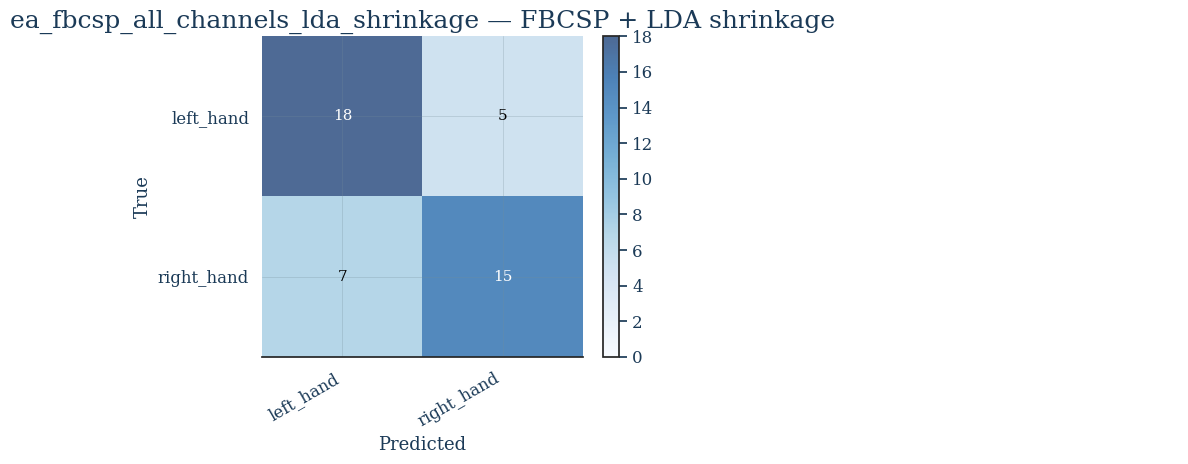

In [37]:
def plot_confusion_matrices(predictions, y_true, normalize=None, title_prefix=""):
    models = list(predictions.keys())
    n_models = len(models)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.8 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, model_name in zip(axes, models):
        cm = confusion_matrix_fixed(y_true, predictions[model_name], normalize=normalize)
        im = ax.imshow(cm, cmap="Blues", vmin=0, alpha=0.72)

        ax.set_title(f"{title_prefix}{model_name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(np.arange(len(LABEL_NAMES)))
        ax.set_yticks(np.arange(len(LABEL_NAMES)))
        ax.set_xticklabels(LABEL_NAMES, rotation=30, ha="right")
        ax.set_yticklabels(LABEL_NAMES)

        threshold = np.nanmax(cm) / 2 if np.nanmax(cm) > 0 else 0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                value = cm[i, j]
                text = f"{value:.2f}" if normalize else f"{int(value)}"
                ax.text(j, i, text, ha="center", va="center",
                        color="white" if value > threshold else "black", fontsize=11)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[len(models):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if ACTIVE_VARIANT not in final_predictions_by_variant:
    raise ValueError(f"ACTIVE_VARIANT={ACTIVE_VARIANT} no existe. Opciones: {list(final_predictions_by_variant)}")

plot_confusion_matrices(
    final_predictions_by_variant[ACTIVE_VARIANT],
    variant_payloads[ACTIVE_VARIANT]["y_test"],
    normalize=None,
    title_prefix=f"{ACTIVE_VARIANT} — ",
)


## 12.1 Visualización 2D de predicciones supervisadas

Proyección 2D — first two standardized FBCSP features
Puntos mostrados: 45 / 45


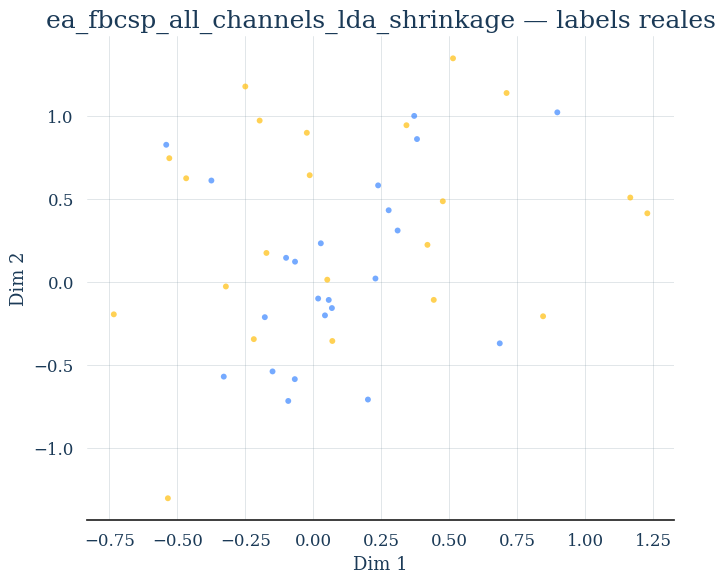

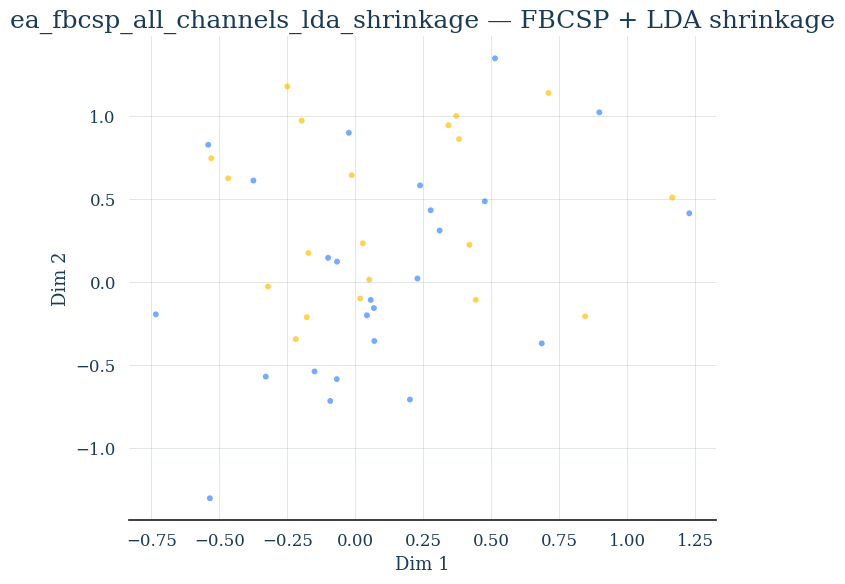

In [38]:
def project_features_2d(X_train, X_eval):
    """Proyección 2D simple usando las dos primeras features finales."""
    X_eval = np.asarray(X_eval)
    if X_eval.shape[1] == 1:
        return None, np.column_stack([X_eval[:, 0], np.zeros(X_eval.shape[0])]), "feature_1 + zero axis"
    return None, X_eval[:, :2], "first two standardized FBCSP features"


def label_colors_for_binary(values):
    palette = {1: "#3a86ff", 2: "#ffbe0b"}
    return [palette.get(int(v), "#999999") for v in values]


def plot_2d_predictions_for_variant(variant_name, max_points=None):
    payload = variant_payloads[variant_name]
    X_test = payload["X_test"]
    y_test = payload["y_test"]
    predictions = final_predictions_by_variant[variant_name]
    _, Z_test, projection_info = project_features_2d(payload["X_dev"], X_test)

    if max_points is not None and len(Z_test) > max_points:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(Z_test), size=max_points, replace=False)
    else:
        idx = np.arange(len(Z_test))

    print(f"Proyección 2D — {projection_info}")
    print(f"Puntos mostrados: {len(idx)} / {len(Z_test)}")

    for title, values in [("labels reales", y_test), *[(name, pred) for name, pred in predictions.items()]]:
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(Z_test[idx, 0], Z_test[idx, 1], c=label_colors_for_binary(values[idx]), s=18, alpha=0.70, edgecolors="none")
        if title != "labels reales":
            err = idx[values[idx] != y_test[idx]]
            if len(err) > 0:
                ax.scatter(Z_test[err, 0], Z_test[err, 1], facecolors="none", edgecolors="black", marker="x", s=28, linewidths=0.8)
        ax.set_title(f"{variant_name} — {title}")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

plot_2d_predictions_for_variant(ACTIVE_VARIANT, max_points=None)


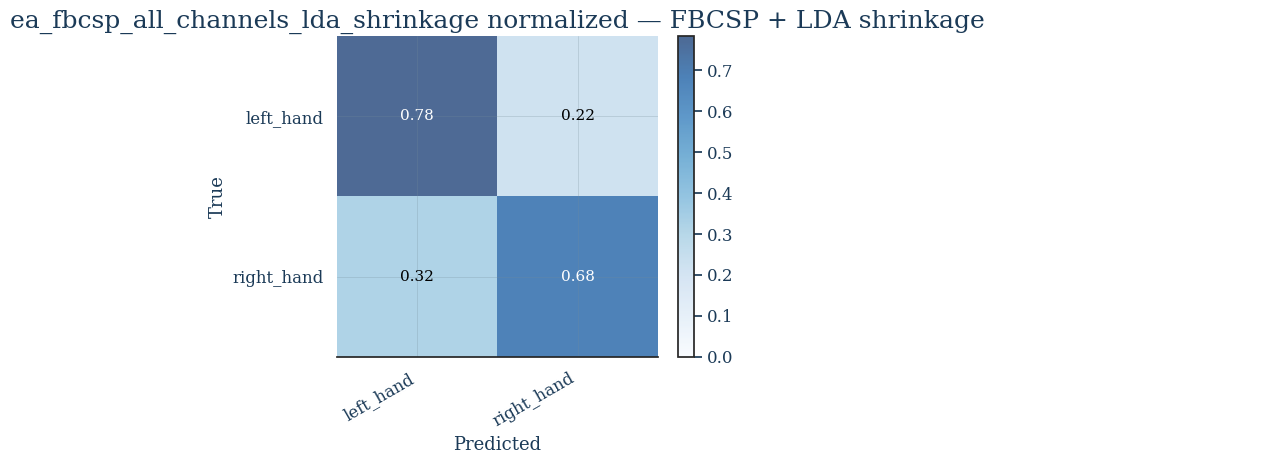

In [39]:
plot_confusion_matrices(
    final_predictions_by_variant[ACTIVE_VARIANT],
    variant_payloads[ACTIVE_VARIANT]["y_test"],
    normalize="true",
    title_prefix=f"{ACTIVE_VARIANT} normalized — ",
)

## 13. Boxplots por característica después de FBCSP, selección supervisada y estandarización


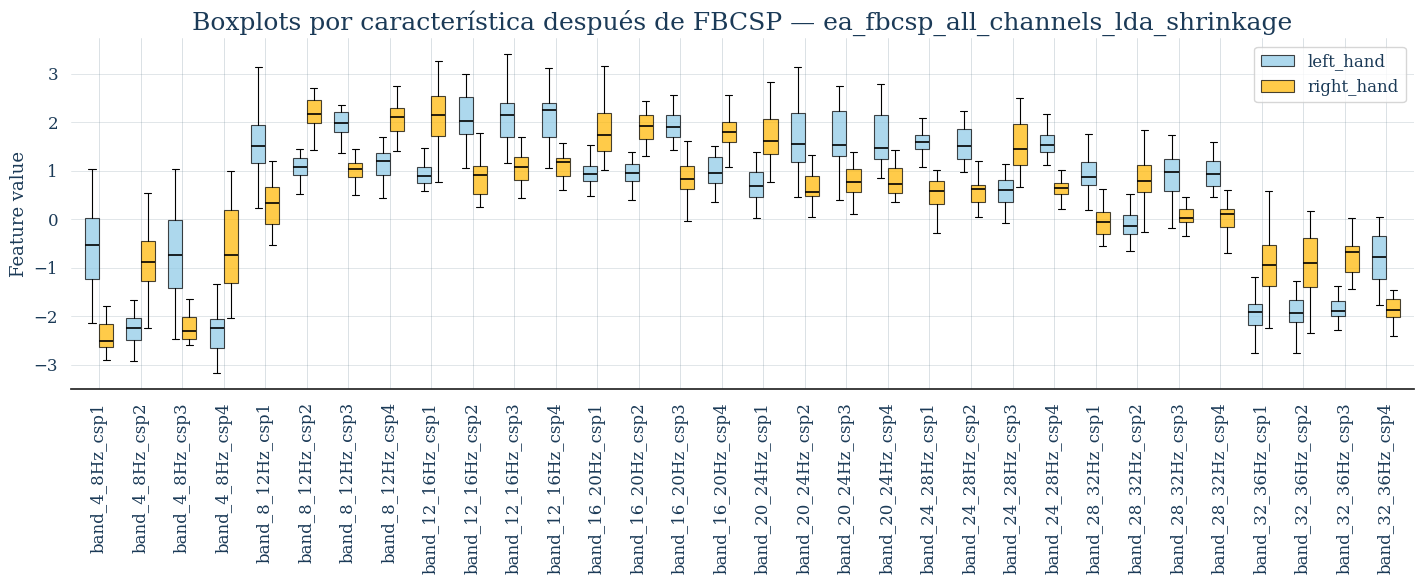

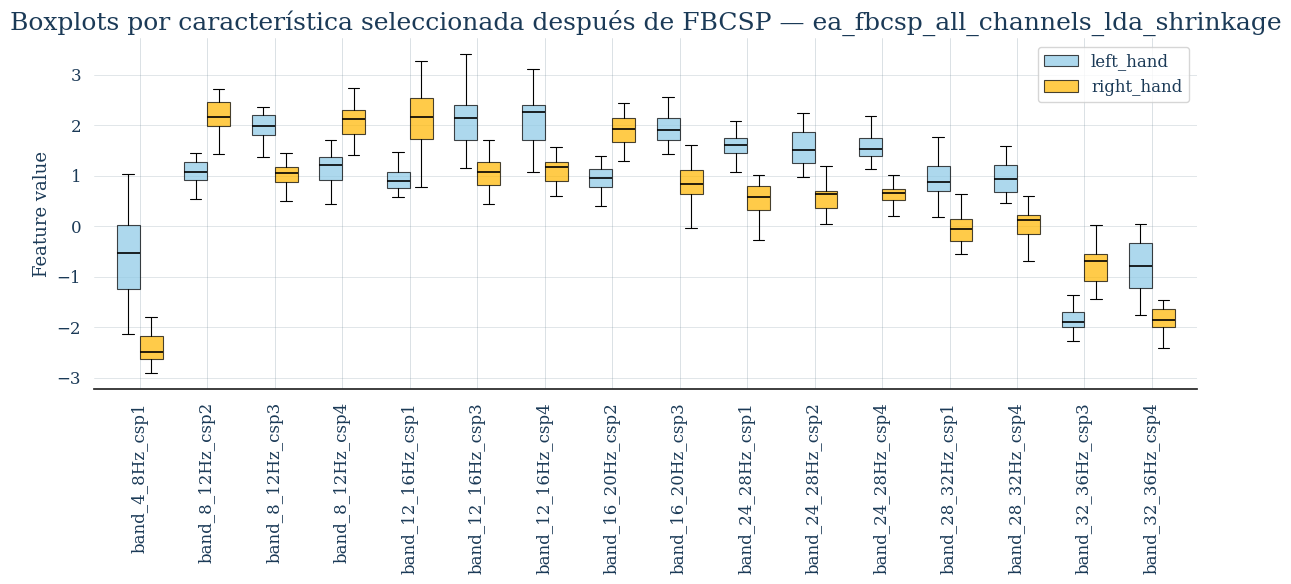

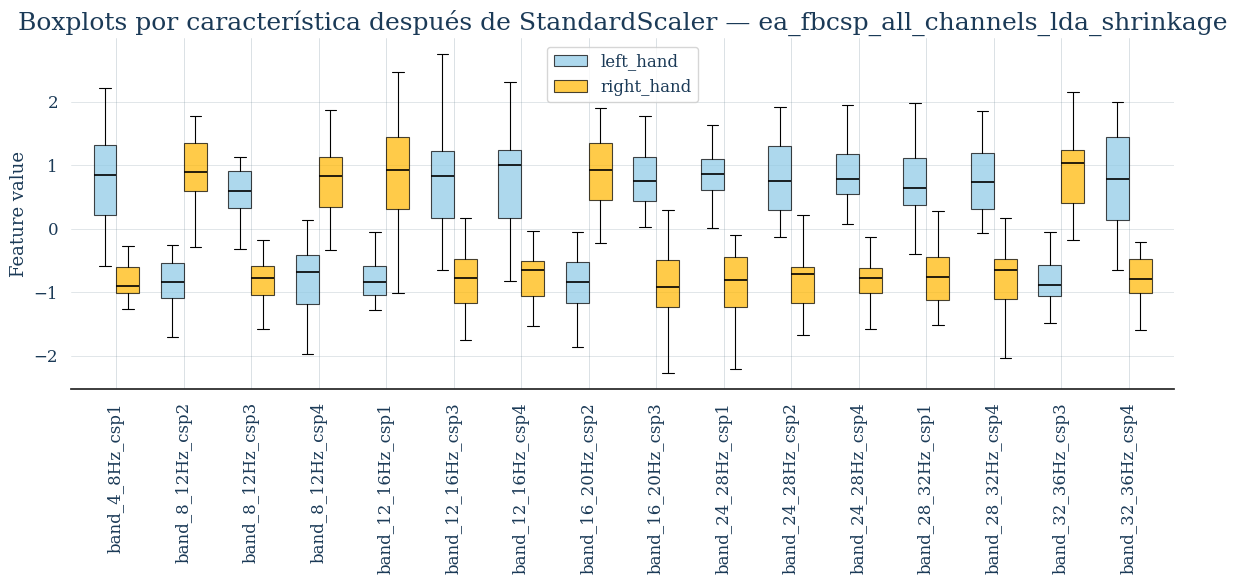

In [41]:
def plot_feature_boxplots_matrix(X, y, feature_names, title, max_features=None):
    """Boxplot por característica con color distinto para cada clase."""
    n_features = X.shape[1] if max_features is None else min(max_features, X.shape[1])
    feature_names = list(feature_names)[:n_features]

    positions = np.arange(n_features)
    width = 0.34
    colors = {
        "left_hand": "#8ecae6",
        "right_hand": "#ffb703",
    }

    fig, ax = plt.subplots(figsize=(max(12, 0.45 * n_features), 6))

    legend_handles = []
    for class_idx, label_id in enumerate(LABEL_ORDER):
        label_name = LABEL_ID_TO_NAME[label_id]
        class_values = [X[y == label_id, fi] for fi in range(n_features)]
        offset = (class_idx - (len(LABEL_ORDER) - 1) / 2) * width
        bp = ax.boxplot(
            class_values,
            positions=positions + offset,
            widths=width,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.2},
            boxprops={"linewidth": 0.8},
            whiskerprops={"linewidth": 0.8},
            capprops={"linewidth": 0.8},
        )
        for box in bp["boxes"]:
            box.set_facecolor(colors.get(label_name, "#cccccc"))
            box.set_alpha(0.72)
        legend_handles.append(bp["boxes"][0])

    ax.set_xticks(positions)
    ax.set_xticklabels(feature_names, rotation=90)
    ax.set_title(title)
    ax.set_ylabel("Feature value")
    ax.legend(legend_handles, [LABEL_ID_TO_NAME[i] for i in LABEL_ORDER], loc="best")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_fbcsp_and_scaled_boxplots_for_variant(variant_name, max_features=None):
    payload = variant_payloads[variant_name]
    y = payload["y_dev"]
    artifacts = payload.get("artifacts", {}) or {}

    # 1) Después de FBCSP, antes de StandardScaler.
    X_fbcsp = artifacts.get("X_dev_fbcsp")
    fbcsp_names = artifacts.get("fbcsp_feature_names")
    if X_fbcsp is not None and fbcsp_names:
        plot_feature_boxplots_matrix(
            X_fbcsp,
            y,
            fbcsp_names,
            title=f"Boxplots por característica después de FBCSP — {variant_name}",
            max_features=max_features,
        )
    else:
        print(f"[{variant_name}] No hay X_dev_fbcsp guardado. Ejecuta extracción o guarda/carga features con X_dev_fbcsp.")

    # 2) Después de la selección supervisada de características, antes de StandardScaler.
    X_selected = artifacts.get("X_dev_selected")
    selected_names = artifacts.get("selected_feature_names")
    if X_selected is not None and selected_names:
        plot_feature_boxplots_matrix(
            X_selected,
            y,
            selected_names,
            title=f"Boxplots por característica seleccionada después de FBCSP — {variant_name}",
            max_features=max_features,
        )

    # 3) Después de StandardScaler.
    X_final = payload.get("X_dev")
    final_names = artifacts.get("final_feature_names", [f"f{i}" for i in range(X_final.shape[1])])
    plot_feature_boxplots_matrix(
        X_final,
        y,
        final_names,
        title=f"Boxplots por característica después de StandardScaler — {variant_name}",
        max_features=max_features,
    )


# Uso sugerido:
plot_fbcsp_and_scaled_boxplots_for_variant(ACTIVE_VARIANT, max_features=32)


## 14. Celda opcional: cargar features guardadas y continuar desde el modelo

In [ ]:
# Celda opcional de carga de features
# Úsala si ya ejecutaste el pipeline y guardaste las features.
# Flujo recomendado:
# 1) Cambia LOAD_FEATURES_MANUAL = True.
# 2) Ejecuta esta celda.
# 3) Continúa desde la sección 10: modelo y test hold-out final.

# LOAD_FEATURES_MANUAL = False
# if LOAD_FEATURES_MANUAL:
#     variant_payloads = {ACTIVE_VARIANT: load_variant_features(ACTIVE_VARIANT)}
#     print("Features cargadas:", list(variant_payloads.keys()))
